In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

# 학습 모델 저장을 위한 라이브러리
import pickle

### 시계열 기반 세그먼트 변화 분석
- 목표 : 시간 흐름에 따라 이탈율과 세그먼트 구성이 어떻게 변해왔는지를 분석
- 이를 통해 고객 행동의 변화 시점과 세그먼트의 이동 경향을 파악할 수 있음.

In [3]:
#기준일 기준 이탈 정의
reference_date = pd.to_datetime("2023-01-01")
churn_cutoff = reference_date - pd.DateOffset(months=6)

#### 월별 이탈률 계산 방식
- 고객의 마지막 주문 월을 기준으로 groupby
- 해당 월 기준으로 chun_rate체크
- 매월 전체 고객 대비 이탈 고객 비율 계산

In [5]:
import pandas as pd

# 데이터 불러오기
orders = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv', parse_dates=['created_at'])

# 고객별 마지막 주문일 계산
last_order = orders.groupby('user_id')['created_at'].max().reset_index()
last_order['churn_date'] = last_order['created_at'] + pd.DateOffset(months=6)

# 전체 분석 대상 월 목록
months = pd.date_range(start='2019-01-01', end='2022-12-01', freq='MS').to_period('M')

# 결과 저장용 리스트
records = []

for _, row in last_order.iterrows():
    user = row['user_id']
    churn_month = row['churn_date'].to_period('M')
    
    for month in months:
        is_churn = int(month >= churn_month)
        records.append({
            'user_id': user,
            'month': str(month),
            'is_churn': is_churn
        })

# 결과 DataFrame 생성
churn_ts_df = pd.DataFrame(records)

# 결과 미리보기
print(churn_ts_df.head())

   user_id    month  is_churn
0        1  2019-01         0
1        1  2019-02         0
2        1  2019-03         0
3        1  2019-04         0
4        1  2019-05         0


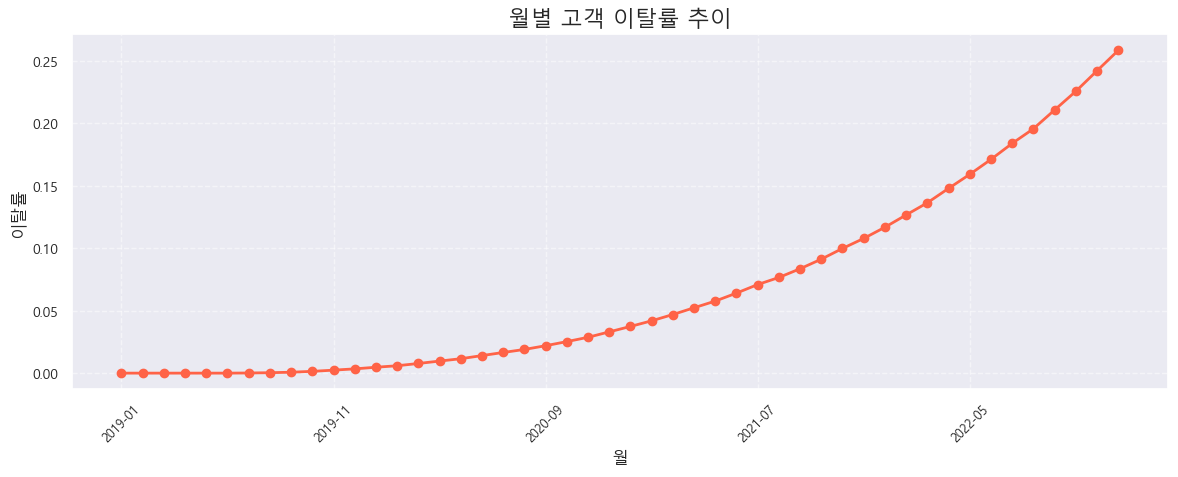

In [6]:
# 월별 평균 이탈률 계산
monthly_churn_rate = churn_ts_df.groupby('month')['is_churn'].mean()

# 시각화
plt.figure(figsize=(12, 5))
monthly_churn_rate.plot(marker='o', color='tomato', linewidth=2)

plt.title('월별 고객 이탈률 추이', fontsize=16)
plt.xlabel('월', fontsize=12)
plt.ylabel('이탈률', fontsize=12)
plt.xticks(rotation=45, fontsize=9)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

- 월별 이탈률은 시간이 흐름에 따라 꾸준히 올라가고 있다.
1) 제품/서비스 만족도 저하 의심
2) 경쟁 심화
3) 마케팅 또는 리텐션 정책 약화
   

### 세그먼트 별 이탈률 계산
- 목표 : RFM기반으로 나눈 세그먼트 별 이탈률이 시간에 따라 어떻게 달라지는지 확인
- 마케팅 리소스를 어디에 집중할지에 대한 판단 근거 마련

In [9]:
orders = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv")
order_items = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/order_items_EDA.csv")

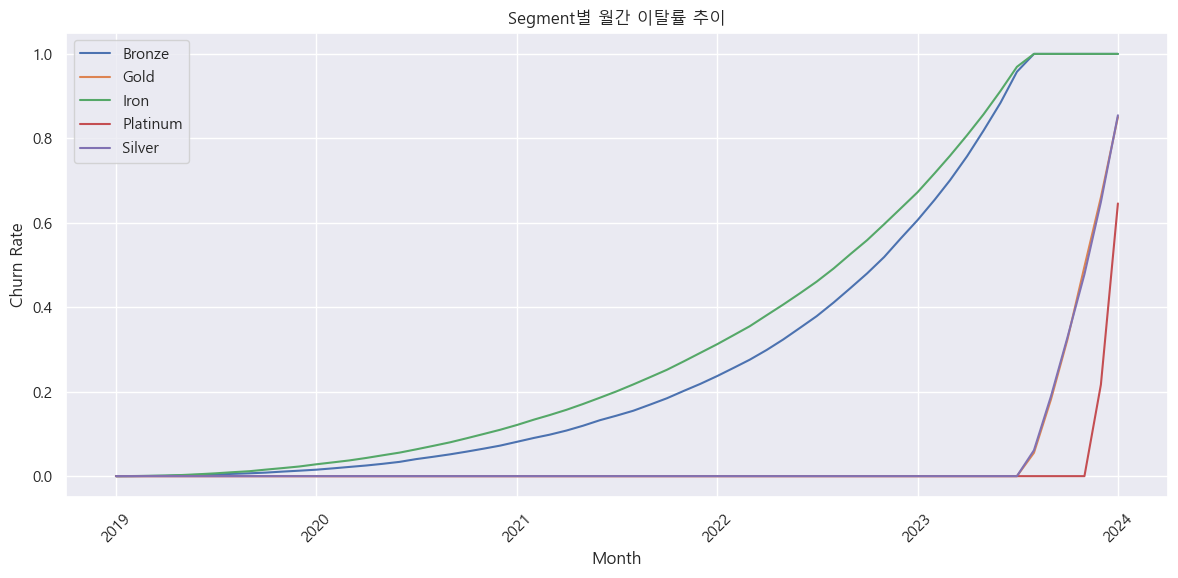

In [10]:
# === 2. 날짜 및 숫자형 처리 ===
orders['created_at'] = pd.to_datetime(orders['created_at'])
order_items['sale_price'] = pd.to_numeric(order_items['sale_price'], errors='coerce')

# === 3. 주문별 총 결제 금액 계산 ===
order_items['total_price'] = order_items['sale_price']
order_price = order_items.groupby('order_id')['total_price'].sum().reset_index()

# === 4. orders에 결제금액 붙이기 ===
if 'total_price' in orders.columns:
    orders = orders.drop(columns=['total_price'])

orders = orders.merge(order_price, on='order_id', how='left')

# === 5. 기준일 지정 (분석 시점 마지막 날짜, tz-naive 통일) ===
if orders['created_at'].dt.tz is not None:
    orders['created_at'] = orders['created_at'].dt.tz_localize(None)

reference_date = orders['created_at'].max().normalize()

# === 6. RFM 계산 ===
# Recency
recency_df = orders.groupby('user_id')['created_at'].max().reset_index()
recency_df['Recency'] = (reference_date - recency_df['created_at']).dt.days

# Frequency
frequency_df = orders.groupby('user_id')['order_id'].nunique().reset_index()
frequency_df.columns = ['user_id', 'Frequency']

# Monetary
monetary_df = orders.groupby('user_id')['total_price'].sum().reset_index()
monetary_df.columns = ['user_id', 'Monetary']

# RFM 통합
rfm = recency_df.merge(frequency_df, on='user_id').merge(monetary_df, on='user_id')

# === 7. RFM 점수화 (1~5 점수) ===
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

# === 8. 고객 세그먼트 분류 함수 ===
def segment(row):
    if row['RFM_Score'] == '555':
        return 'Platinum'
    elif int(row['R']) >= 4 and int(row['F']) >= 4:
        return 'Gold'
    elif int(row['R']) >= 4:
        return 'Silver'
    elif int(row['M']) >= 4:
        return 'Bronze'
    else:
        return 'Iron'

rfm['Segment'] = rfm.apply(segment, axis=1)

# === 9. orders에 Segment 붙이기 ===
if 'Segment' in orders.columns:
    orders = orders.drop(columns=['Segment'])

orders = orders.merge(rfm[['user_id', 'Segment']], on='user_id', how='left')

# === 10. 월별 주문 생성 및 마지막 주문월 ===
orders['order_month'] = orders['created_at'].dt.to_period('M')
last_orders = orders.groupby(['user_id', 'Segment'])['created_at'].max().reset_index()
last_orders['last_order_month'] = last_orders['created_at'].dt.to_period('M')

# === 11. 전체 분석 기간 월별 생성 ===
all_months = pd.period_range('2019-01', reference_date.to_period('M'), freq='M')

# === 12. 고객-월 매트릭스 생성 ===
user_segments = last_orders[['user_id', 'Segment']].drop_duplicates()
matrix = pd.DataFrame([
    {'user_id': row.user_id, 'Segment': row.Segment, 'month': month}
    for _, row in user_segments.iterrows()
    for month in all_months
])
matrix['month'] = matrix['month'].astype(str)

# === 13. 마지막 주문월과 비교해 이탈 여부 판단 ===
last_orders['last_order_month'] = last_orders['last_order_month'].astype(str)
matrix = matrix.merge(last_orders[['user_id', 'last_order_month']], on='user_id', how='left')
matrix['is_churned'] = matrix['month'] > matrix['last_order_month']

# === 14. 세그먼트별 월간 이탈률 계산 ===
churn_summary = matrix.groupby(['month', 'Segment'])['is_churned'].mean().reset_index()
churn_summary['month'] = pd.to_datetime(churn_summary['month'])

# === 15. 시각화 ===
plt.figure(figsize=(12, 6))
for segment in churn_summary['Segment'].unique():
    segment_data = churn_summary[churn_summary['Segment'] == segment]
    plt.plot(segment_data['month'], segment_data['is_churned'], label=segment)

plt.legend()
plt.title('Segment별 월간 이탈률 추이')
plt.ylabel('Churn Rate')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

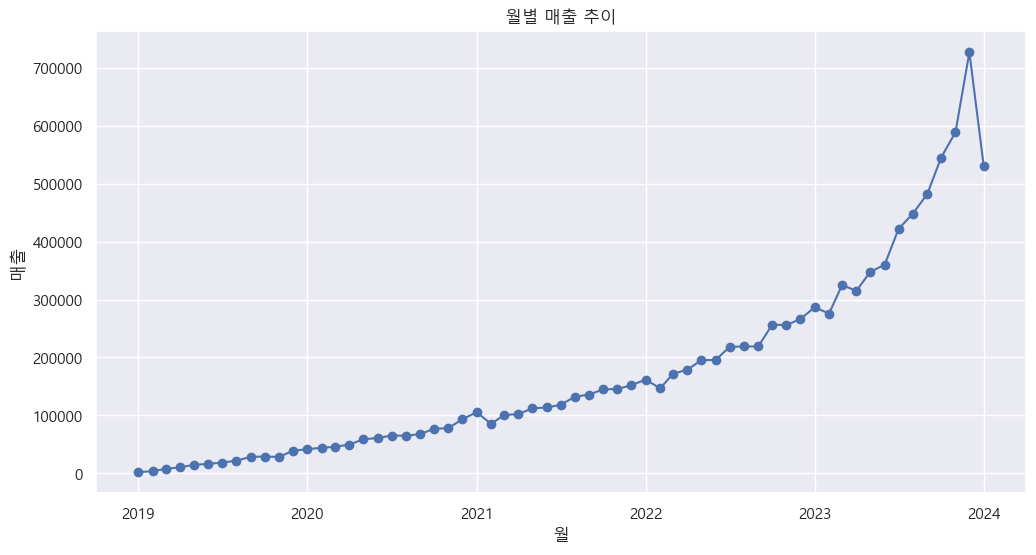

In [11]:
# 월별 매출 추이
monthly_sales = orders.groupby(orders['created_at'].dt.to_period('M'))['total_price'].sum().reset_index()
monthly_sales.columns = ['Month', 'TotalSales']
monthly_sales['Month'] = monthly_sales['Month'].dt.to_timestamp()

# 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Month'], monthly_sales['TotalSales'], marker='o')
plt.title('월별 매출 추이')
plt.xlabel('월')
plt.ylabel('매출')
plt.grid(True)
plt.show()

In [12]:
segment_summary = orders.groupby('Segment').agg({
    'user_id': pd.Series.nunique,
    'total_price': 'sum',
    'order_id': pd.Series.nunique
}).reset_index()

segment_summary.columns = ['Segment', '고객 수', '총 매출', '주문 수']
segment_summary.sort_values(by='총 매출', ascending=False)

,Segment,고객 수,총 매출,주문 수
0,Bronze,16764,4.141850e+06,31309
1,Gold,13193,2.510160e+06,31277
2,Iron,30062,1.585262e+06,35352
4,Silver,15538,1.349520e+06,15538
3,Platinum,2580,9.725770e+05,8687


In [13]:
# 월 기준 추출
orders['order_month'] = orders['created_at'].dt.to_period('M')

# 월별 기준일 설정
monthly_rfm_list = []

for month in sorted(orders['order_month'].unique()):
    month_orders = orders[orders['order_month'] <= month].copy()
    ref_date = month.to_timestamp() + pd.offsets.MonthEnd(0)

    rfm = month_orders.groupby('user_id').agg({
        'created_at': lambda x: (ref_date - x.max()).days,
        'order_id': 'count',
        'total_price': 'sum'
    }).reset_index()
    
    rfm.columns = ['user_id', 'Recency', 'Frequency', 'Monetary']

    # RFM 점수 계산 (5등분)
    rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
    rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
    rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

    rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
    
    # Segment 함수 적용
    def segment(row):
        if row['RFM_Score'] == '555':
            return 'Platinum'
        elif row['R'] >= 4 and row['F'] >= 4:
            return 'Gold'
        elif row['R'] >= 4:
            return 'Silver'
        elif row['M'] >= 4:
            return 'Bronze'
        else:
            return 'Iron'

    rfm['Segment'] = rfm.apply(segment, axis=1)
    rfm['Month'] = month.to_timestamp()
    
    monthly_rfm_list.append(rfm[['user_id', 'Month', 'Segment']])

In [14]:
rfm_segment_timeline = pd.concat(monthly_rfm_list)

# 피벗 테이블: 고객별 월별 Segment 변화
segment_pivot = rfm_segment_timeline.pivot(index='user_id', columns='Month', values='Segment')

In [15]:
pip install plotly

In [16]:
# 1. 주문 날짜를 월 단위로 변환
orders['order_month'] = orders['created_at'].dt.to_period('M')

# 2. user_id와 order_month로 유일 조합 추출
user_month_df = orders[['user_id', 'order_month']].drop_duplicates()

# 3. user_id 기준으로 rfm Segment를 붙여주기
user_month_df = user_month_df.merge(rfm[['user_id', 'Segment']], on='user_id', how='left')

# 4. Period → datetime으로 변환 (시계열 정렬 위해)
user_month_df['Month'] = user_month_df['order_month'].dt.to_timestamp()

# 5. Sankey 다이어그램용 원본
rfm_segment_timeline = user_month_df[['user_id', 'Month', 'Segment']].dropna()

In [17]:
import pandas as pd

# 월 단위로 주문 생성
orders['order_month'] = orders['created_at'].dt.to_period('M')

# user_id, 월별 Segment 재계산
user_month_df = orders[['user_id', 'order_month']].drop_duplicates()
user_month_df['Month'] = user_month_df['order_month'].dt.to_timestamp()

# 사용자별 최신 주문 기준 Segment 가져오기
latest_rfm = rfm[['user_id', 'Segment']]
rfm_segment_timeline = user_month_df.merge(latest_rfm, on='user_id', how='left')

# 정렬
rfm_segment_timeline = rfm_segment_timeline.sort_values(by=['user_id', 'Month'])

In [18]:
# 1. 노드: "월_Segment" 조합
transition_df['source_node'] = transition_df['Month'].astype(str) + '_' + transition_df['Segment']
transition_df['target_node'] = transition_df['Next_Month'].astype(str) + '_' + transition_df['Next_Segment']

# 2. 노드 전체 목록
all_nodes = pd.unique(transition_df[['source_node', 'target_node']].values.ravel())
node_dict = {node: idx for idx, node in enumerate(all_nodes)}

# 3. source, target, value 매핑
transition_df['source_id'] = transition_df['source_node'].map(node_dict)
transition_df['target_id'] = transition_df['target_node'].map(node_dict)

# 4. source-target별 수치 집계
link_df = transition_df.groupby(['source_id', 'target_id']).size().reset_index(name='count')

# 5. 라벨 (노드 이름 리스트)
labels = [node for node in node_dict]

# 6. Sankey 다이어그램 생성
fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="gray", width=0.5),
        label=labels,
        color="lightsteelblue"
    ),
    link=dict(
        source=link_df['source_id'],
        target=link_df['target_id'],
        value=link_df['count'],
        color='rgba(100,150,255,0.4)',
        hovertemplate='From %{source.label} → %{target.label}<br>Count: %{value}<extra></extra>'
    )
)])

fig.update_layout(
    title_text="고객 세그먼트 월별 이동 흐름 (Sankey Diagram)",
    font=dict(size=14),
    height=1200,
    width=1200,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

NameError: name 'transition_df' is not defined

In [ ]:
import plotly.express as px

# 1. 월별 세그먼트 수 계산
heatmap_df = (
    rfm_segment_timeline
    .groupby(['Month', 'Segment'])
    .size()
    .reset_index(name='count')
)

# 2. 피벗 테이블 생성 (행: 세그먼트, 열: 월)
pivot_table = heatmap_df.pivot(index='Segment', columns='Month', values='count').fillna(0)

# 3. 히트맵 그리기
fig = px.imshow(
    pivot_table,
    labels=dict(x="월", y="세그먼트", color="고객 수"),
    x=pivot_table.columns.astype(str),
    y=pivot_table.index,
    color_continuous_scale='Blues'
)

fig.update_layout(
    title="세그먼트별 월별 고객 수 (Heatmap)",
    xaxis_title="Month",
    yaxis_title="Segment",
    width=1000,
    height=600
)

fig.show()

### 유지율/이탈율 계산

In [24]:
# 사용자 기준으로 이전 달 세그먼트와 다음 달 세그먼트를 비교
rfm_segment_timeline = rfm_segment_timeline.sort_values(by=['user_id', 'Month'])

# 이전 세그먼트를 한 줄 아래로 내려서 현재 달과 비교할 수 있게
rfm_segment_timeline['Prev_Segment'] = rfm_segment_timeline.groupby('user_id')['Segment'].shift(1)
rfm_segment_timeline['Prev_Month'] = rfm_segment_timeline.groupby('user_id')['Month'].shift(1)

# 같은 유저의 연속된 달만 분석
transitions = rfm_segment_timeline.dropna(subset=['Prev_Segment'])

# 유지 여부 판단
transitions['retained'] = transitions['Segment'] == transitions['Prev_Segment']

In [26]:
# 각 세그먼트의 유지 / 이탈 수 계산
segment_retention_stats = transitions.groupby('Prev_Segment')['retained'].agg(
    total='count',
    retained='sum'
).reset_index()

# 비율 계산
segment_retention_stats['retention_rate'] = segment_retention_stats['retained'] / segment_retention_stats['total']
segment_retention_stats['churn_rate'] = 1 - segment_retention_stats['retention_rate']

segment_retention_stats = segment_retention_stats.rename(columns={'Prev_Segment': 'Segment'})

In [28]:
# 1. 데이터 정렬 및 이전 세그먼트 가져오기
rfm_segment_timeline = rfm_segment_timeline.sort_values(by=['user_id', 'Month'])
rfm_segment_timeline['Prev_Segment'] = rfm_segment_timeline.groupby('user_id')['Segment'].shift(1)

# 2. 연속된 달 필터링 (이전 세그먼트가 있는 행만)
transitions = rfm_segment_timeline.dropna(subset=['Prev_Segment'])

# 3. 유지 여부 판단
transitions['retained'] = transitions['Segment'] == transitions['Prev_Segment']

# 4. 세그먼트별 유지/이탈 집계
segment_retention_stats = transitions.groupby('Prev_Segment')['retained'].agg(
    total='count',
    retained='sum'
).reset_index()

# 5. 비율 계산
segment_retention_stats['retention_rate'] = segment_retention_stats['retained'] / segment_retention_stats['total']
segment_retention_stats['churn_rate'] = 1 - segment_retention_stats['retention_rate']

segment_retention_stats = segment_retention_stats.rename(columns={'Prev_Segment': 'Segment'})

# 6. 표 출력
print(segment_retention_stats)

# 7. 시각화 준비 (막대그래프)
df_melt = segment_retention_stats.melt(
    id_vars='Segment',
    value_vars=['retention_rate', 'churn_rate'],
    var_name='Metric',
    value_name='Rate'
)

# 8. 시각화 그리기
fig = px.bar(
    df_melt,
    x='Segment',
    y='Rate',
    color='Metric',
    barmode='group',
    text=df_melt['Rate'].apply(lambda x: f"{x:.1%}"),
    title='세그먼트별 유지율 및 이탈율',
    labels={'Rate': '비율', 'Segment': '세그먼트'}
)

fig.update_traces(textposition='outside')
fig.update_layout(yaxis_tickformat='.0%', yaxis_range=[0,1])

fig.show()

    Segment  total  retained  retention_rate  churn_rate
0    Bronze  13765     13765             1.0         0.0
1      Gold  16006     16006             1.0         0.0
2      Iron   5042      5042             1.0         0.0
3  Platinum   4888      4888             1.0         0.0


NameError: name 'px' is not defined

### 정상적인 유지율/이탈율이 나오지 않는 이유
- 구매횟수 부족

### F가 높지만 M이 낮은 고객군은 소액을 자주 구매하는 저가 충성 고객층일 가능성이 높다

In [32]:
# F 상위 25%, M 하위 25% 기준값 계산
f_75 = rfm['Frequency'].quantile(0.75)
m_25 = rfm['Monetary'].quantile(0.25)

# 소액 다건 구매 고객군 추출
target_customers = rfm[(rfm['Frequency'] >= f_75) & (rfm['Monetary'] <= m_25)]

print(f"해당 조건에 맞는 고객 수: {len(target_customers)}명")
print(target_customers[['user_id', 'Frequency', 'Monetary']].head())

해당 조건에 맞는 고객 수: 886명
     user_id  Frequency   Monetary
108      141          2  39.950001
277      364          2  29.300000
428      548          2  30.380000
634      802          2  26.980000
659      832          2  22.920000


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 기준 월 설정
target_month = pd.Timestamp('2023-12-31')
rfm = monthly_rfm_df[monthly_rfm_df['Month'] == target_month].copy()

# Frequency가 최대치(2)인 고객 중, Monetary가 하위 25%인 고객
monetary_25 = rfm[rfm['Frequency'] == 2]['Monetary'].quantile(0.25)

target_customers = rfm[(rfm['Frequency'] == 2) & (rfm['Monetary'] <= monetary_25)]

print(f" {target_month.date()} 기준, 가설 고객 수: {len(target_customers)}명")
print(target_customers[['user_id', 'Frequency', 'Monetary']].head())

# 시각화: 해당 고객 vs 전체
rfm['Group'] = rfm['user_id'].apply(lambda x: 'Target' if x in target_customers['user_id'].values else 'Others')

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.boxplot(x='Group', y='Monetary', data=rfm[rfm['Frequency'] == 2])
plt.title(' 2회 구매 고객 중 Monetary 비교')
plt.tight_layout()
plt.show()

NameError: name 'monthly_rfm_df' is not defined

### 충성 고객층 분리
- 충성고객 정의 :  최근에 구매했고, 금액이 평균 이상이며, 구매 횟수가 2회 이상인 고객

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------
# 1. Frequency 3+ 통합
# ----------------------
rfm['Frequency'] = rfm['Frequency'].apply(lambda x: 3 if x >= 3 else x)

# 분위수 계산
m_30 = rfm['Monetary'].quantile(0.30)
r_30 = rfm['Recency'].quantile(0.30)
r_40 = rfm['Recency'].quantile(0.40)

# ----------------------
# 2. 충성고객 세그먼트 정의
# ----------------------
def loyalty_segment(row):
    if row['Frequency'] >= 3 and row['Monetary'] >= m_30 and row['Recency'] <= r_30:
        return 'VIP'
    elif row['Frequency'] == 2 and row['Monetary'] >= m_30 and row['Recency'] <= r_40:
        return 'Gold'
    elif row['Frequency'] == 1 and row['Monetary'] >= m_30 and row['Recency'] <= r_30:
        return 'Silver'
    else:
        return 'General'

rfm['LoyaltySegment'] = rfm.apply(loyalty_segment, axis=1)

# ----------------------
# 3. 충성고객 비율
# ----------------------
segment_counts = rfm['LoyaltySegment'].value_counts(normalize=True) * 100
print("충성고객 비율(%)")
print(segment_counts)

충성고객 비율(%)
LoyaltySegment
General    74.828826
Gold       10.930801
Silver      8.275209
VIP         5.965164
Name: proportion, dtype: float64


In [40]:
# 4. 세그먼트별 평균 R/F/M
# ----------------------
avg_rfm = rfm.groupby('LoyaltySegment')[['Recency', 'Frequency', 'Monetary']].mean()
print("\n세그먼트별 평균 R/F/M 값")
print(avg_rfm)


세그먼트별 평균 R/F/M 값
                   Recency  Frequency    Monetary
LoyaltySegment                                   
General         512.942414   1.364552  114.337947
Gold             86.476525   2.000000  186.657559
Silver           65.456078   1.000000  133.395212
VIP              60.219695   3.000000  304.091122


- vip, Gold까지 충성고객으로 분류 가능 (약 17%)

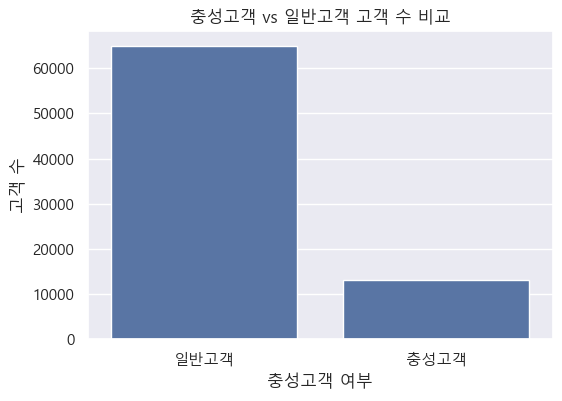

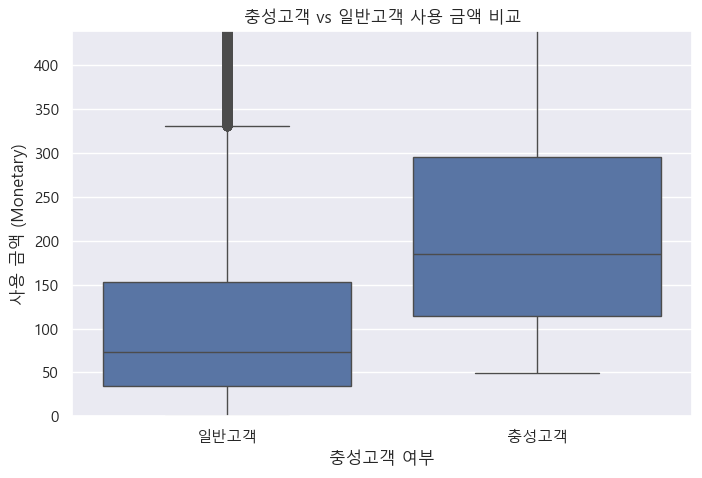

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 충성고객 여부 컬럼 (VIP+Gold)
rfm['IsLoyal'] = rfm['LoyaltySegment'].isin(['VIP', 'Gold'])

# --- 1) 고객 수 비교 그래프 ---
plt.figure(figsize=(6,4))
sns.countplot(data=rfm, x='IsLoyal')
plt.title('충성고객 vs 일반고객 고객 수 비교')
plt.xlabel('충성고객 여부')
plt.ylabel('고객 수')
plt.xticks([0,1], ['일반고객', '충성고객'])
plt.show()

# --- 2) 사용 금액(Monetary) 비교 그래프 ---
plt.figure(figsize=(8,5))
sns.boxplot(data=rfm, x='IsLoyal', y='Monetary')
plt.title('충성고객 vs 일반고객 사용 금액 비교')
plt.xlabel('충성고객 여부')
plt.ylabel('사용 금액 (Monetary)')
plt.xticks([0,1], ['일반고객', '충성고객'])
plt.ylim(0, rfm['Monetary'].quantile(0.95)*1.1)  # 극단치 영향 줄이기 위해 95% 분위수까지만 표시
plt.show()

In [51]:
import pandas as pd

# Frequency 3 이상은 3으로 통합 (기존 전제)
rfm['Frequency'] = rfm['Frequency'].apply(lambda x: 3 if x >= 3 else x)

# 충성고객 여부 (VIP + Gold)
rfm['IsLoyal'] = rfm['LoyaltySegment'].isin(['VIP', 'Gold'])

# 1) 고객별 평균 주문 금액 (AOV) 계산
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency'].replace(0, 1)  # 구매횟수 0 방지용 1로 대체

# 2) 그룹별 AOV 평균
aov_mean = rfm.groupby('IsLoyal')['AOV'].mean()
print("평균 주문 금액(AOV) 비교")
print(aov_mean)

# 3) 그룹별 CLV (총 구매 금액) 평균
clv_mean = rfm.groupby('IsLoyal')['Monetary'].mean()
print("\n고객 생애가치(CLV) 비교")
print(clv_mean)

평균 주문 금액(AOV) 비교
IsLoyal
False    86.407809
True     96.165531
Name: AOV, dtype: float64

고객 생애가치(CLV) 비교
IsLoyal
False    116.235603
True     228.117780
Name: Monetary, dtype: float64


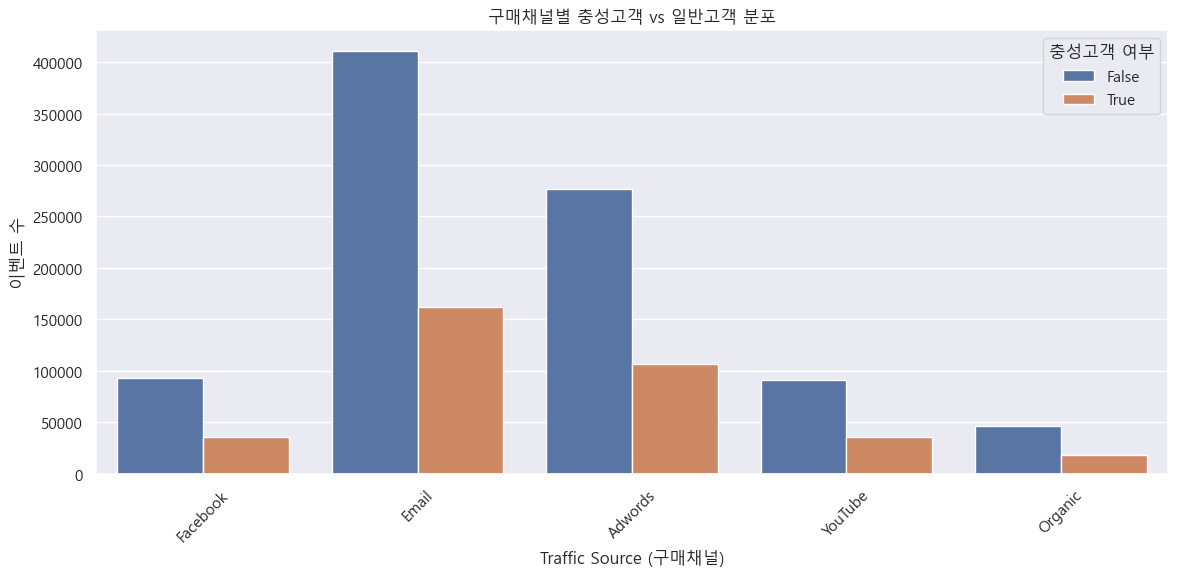

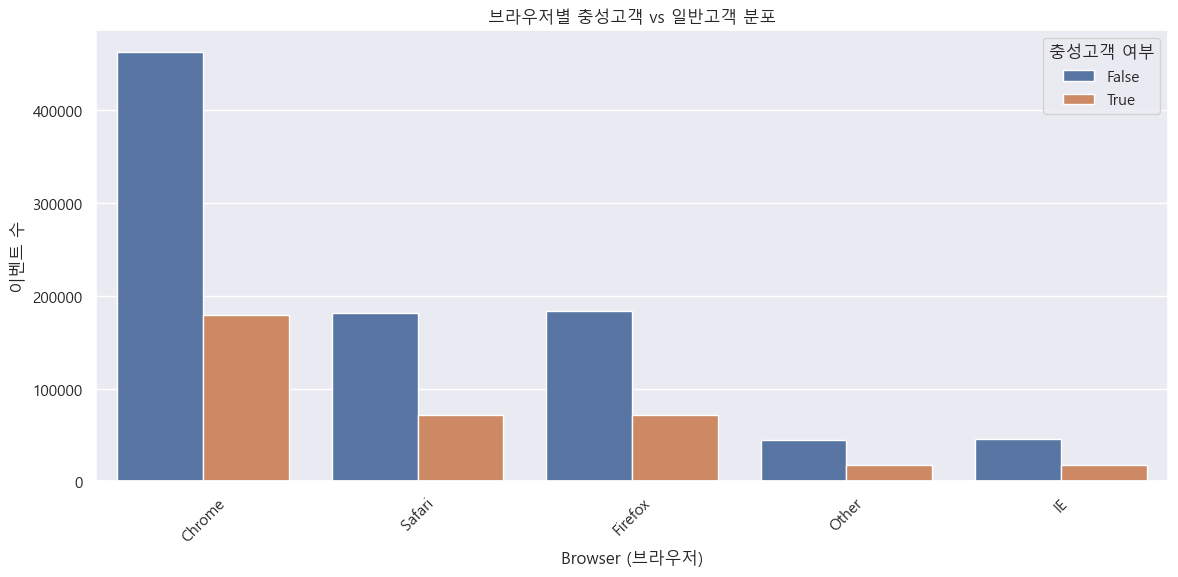

In [53]:
# 1. events 데이터 불러오기
events = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/events_EDA.csv', parse_dates=['created_at'])

# 2. rfm 데이터 user_id, IsLoyal 컬럼 준비
rfm_subset = rfm[['user_id', 'IsLoyal']].drop_duplicates()

# 3. events와 rfm 병합 (user_id 기준)
events_rfm = pd.merge(events, rfm_subset, left_on='user_id', right_on='user_id', how='inner')

# 4. 구매채널(traffic_source)별 분포 (충성고객/일반고객 비율)
plt.figure(figsize=(12,6))
sns.countplot(data=events_rfm, x='traffic_source', hue='IsLoyal')
plt.title('구매채널별 충성고객 vs 일반고객 분포')
plt.xticks(rotation=45)
plt.xlabel('Traffic Source (구매채널)')
plt.ylabel('이벤트 수')
plt.legend(title='충성고객 여부')
plt.tight_layout()
plt.show()

# 5. 브라우저(browser)별 분포 (충성고객/일반고객 비율)
plt.figure(figsize=(12,6))
sns.countplot(data=events_rfm, x='browser', hue='IsLoyal')
plt.title('브라우저별 충성고객 vs 일반고객 분포')
plt.xticks(rotation=45)
plt.xlabel('Browser (브라우저)')
plt.ylabel('이벤트 수')
plt.legend(title='충성고객 여부')
plt.tight_layout()
plt.show()

In [55]:
# orders 데이터 불러오기 (가정: 'is_returned' 컬럼 존재)
orders = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv', parse_dates=['created_at'])

# rfm 데이터에서 user_id, IsLoyal 컬럼 추출
rfm_subset = rfm[['user_id', 'IsLoyal']].drop_duplicates()

# orders와 rfm 병합 (user_id 기준)
orders_rfm = pd.merge(orders, rfm_subset, left_on='user_id', right_on='user_id', how='inner')

# 사용자별 반품률 계산 (반품건수 / 주문건수)
return_rate = orders_rfm.groupby(['user_id', 'IsLoyal'])['is_returned'].mean().reset_index()

# 충성고객/일반고객 평균 반품률 비교
avg_return_rate = return_rate.groupby('IsLoyal')['is_returned'].mean()
print("충성고객 vs 일반고객 평균 반품률")
print(avg_return_rate)

충성고객 vs 일반고객 평균 반품률
IsLoyal
False    0.100626
True     0.098735
Name: is_returned, dtype: float64


- 충성고객들의 반품률이 약간 더 낮은 것을 확인 가능

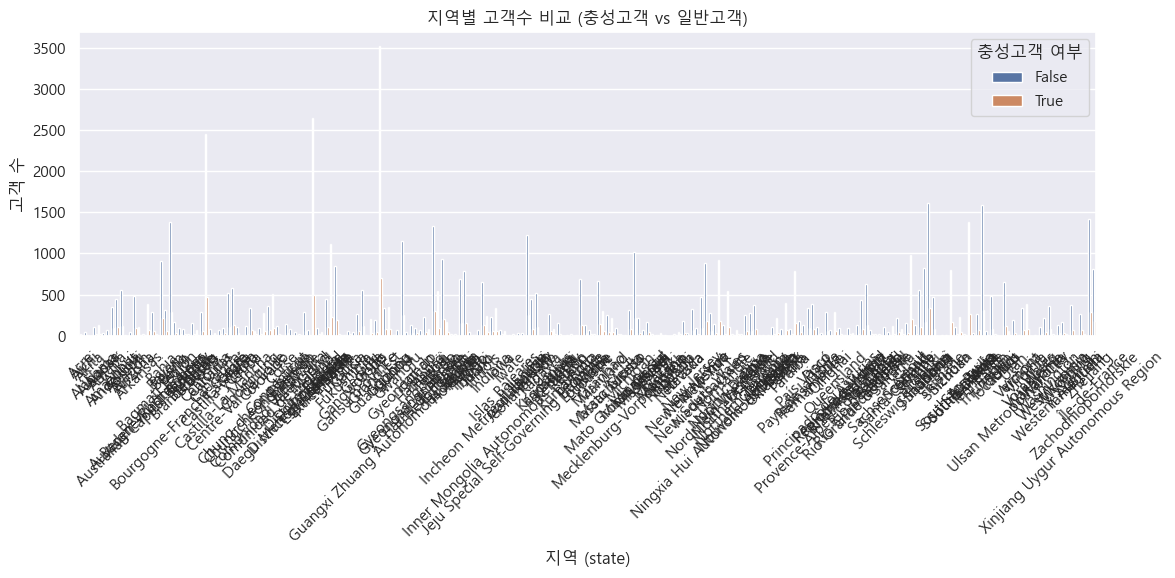

In [58]:
# users 데이터 불러오기
users = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/users_EDA.csv')

# rfm에서 user_id, IsLoyal 추출
rfm_subset = rfm[['user_id', 'IsLoyal']].drop_duplicates()

# users와 rfm 병합
users_rfm = pd.merge(users, rfm_subset, left_on='id', right_on='user_id', how='inner')

# 지역별(예: state) 고객수 집계
region_counts = users_rfm.groupby(['state', 'IsLoyal']).size().reset_index(name='count')

# 시각화
plt.figure(figsize=(12,6))
sns.barplot(data=region_counts, x='state', y='count', hue='IsLoyal')
plt.xticks(rotation=45)
plt.title('지역별 고객수 비교 (충성고객 vs 일반고객)')
plt.xlabel('지역 (state)')
plt.ylabel('고객 수')
plt.legend(title='충성고객 여부')
plt.tight_layout()
plt.show()

- 마케팅 반응성 비교

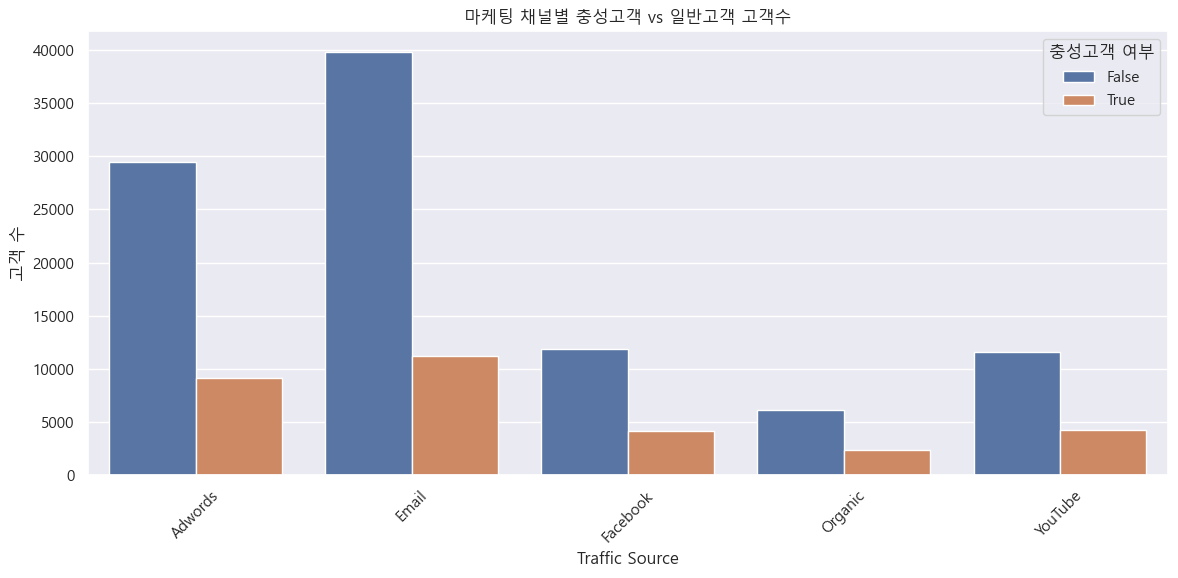

In [60]:
# events 데이터 불러오기
events = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/events_EDA.csv')

# rfm에서 user_id, IsLoyal 추출
rfm_subset = rfm[['user_id', 'IsLoyal']].drop_duplicates()

# events와 rfm 병합
events_rfm = pd.merge(events, rfm_subset, left_on='user_id', right_on='user_id', how='inner')

# traffic_source별 고객수 집계
traffic_counts = events_rfm.groupby(['traffic_source', 'IsLoyal'])['user_id'].nunique().reset_index(name='user_count')

# 시각화
plt.figure(figsize=(12,6))
sns.barplot(data=traffic_counts, x='traffic_source', y='user_count', hue='IsLoyal')
plt.xticks(rotation=45)
plt.title('마케팅 채널별 충성고객 vs 일반고객 고객수')
plt.xlabel('Traffic Source')
plt.ylabel('고객 수')
plt.legend(title='충성고객 여부')
plt.tight_layout()
plt.show()

- 배송센터 별 고객 수 비교

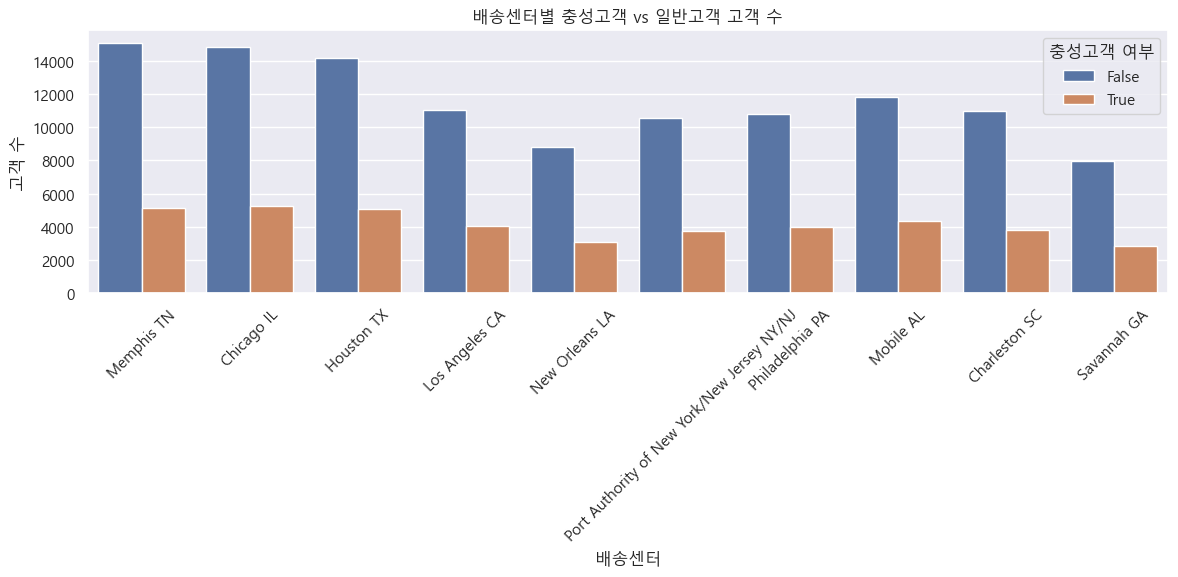

In [66]:
# 1. 배송센터 데이터 불러오기
dist_centers = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/distribution_centers_EDA.csv')  
# ['id', 'name', 'latitude', 'longitude']

# 2. order_items 또는 orders에서 user_id와 배송센터 id 연결 필요  
# 예를 들어 order_items에 inventory_item_id가 있고,
# inventory_items 데이터에서 inventory_item_id와 distribution_center_id 연결 가능

order_items = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/order_items_EDA.csv')
inventory_items = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv')

# 3. order_items + inventory_items 병합 (inventory_item_id 기준)
order_inv = pd.merge(order_items, inventory_items, left_on='inventory_item_id', right_on='id', how='left')

# 4. rfm 데이터에서 user_id, IsLoyal 추출
rfm_subset = rfm[['user_id', 'IsLoyal']].drop_duplicates()

# 5. user_id와 IsLoyal을 order_inv에 병합
order_inv_rfm = pd.merge(order_inv, rfm_subset, left_on='user_id', right_on='user_id', how='inner')

# 6. 배송센터별, 충성고객 여부별 고유 고객 수 집계
center_customer_counts = order_inv_rfm.groupby(['product_distribution_center_id', 'IsLoyal'])['user_id'].nunique().reset_index()

# 7. 배송센터 이름 병합
center_customer_counts = pd.merge(center_customer_counts, dist_centers, left_on='product_distribution_center_id', right_on='id', how='left')

# 8. 시각화
plt.figure(figsize=(12,6))
sns.barplot(data=center_customer_counts, x='name', y='user_id', hue='IsLoyal')
plt.xticks(rotation=45)
plt.title('배송센터별 충성고객 vs 일반고객 고객 수')
plt.xlabel('배송센터')
plt.ylabel('고객 수')
plt.legend(title='충성고객 여부')
plt.tight_layout()
plt.show()

In [69]:
# orders 데이터 불러오기 (가정: 'user_id', 'created_at' 컬럼 존재)
orders = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv', parse_dates=['created_at'])

# 1. user_id별 주문일 정렬
orders_sorted = orders.sort_values(by=['user_id', 'created_at'])

# 2. 그룹별(고객별)로 이전 주문일과의 차이(일) 계산
orders_sorted['prev_order_date'] = orders_sorted.groupby('user_id')['created_at'].shift(1)
orders_sorted['purchase_interval_days'] = (orders_sorted['created_at'] - orders_sorted['prev_order_date']).dt.days

# 3. 고객별 평균 구매주기 계산 (NaN 제외)
avg_purchase_interval = orders_sorted.groupby('user_id')['purchase_interval_days'].mean().reset_index()
avg_purchase_interval.columns = ['user_id', 'avg_purchase_interval_days']

# 4. rfm 데이터와 병합하여 충성고객 여부와 함께 분석 가능
rfm_subset = rfm[['user_id', 'IsLoyal']].drop_duplicates()
avg_purchase_interval = pd.merge(avg_purchase_interval, rfm_subset, on='user_id', how='left')

# 5. 충성고객과 일반고객별 평균 구매주기 비교
print(avg_purchase_interval.groupby('IsLoyal')['avg_purchase_interval_days'].mean())

IsLoyal
False    300.804861
True     242.212316
Name: avg_purchase_interval_days, dtype: float64


### 결론
- 충성고객이란? : 구매 빈도와 총 구매 금액이 높은 고객을 종합하여 분류 가능
- 이번 분석에서는 구매 횟수가 2회 이상이며(데이터의 특성 고려) RFM 점수 내 Gold등급 이상인 고객을 의미한다.
- 이 충성고객들은 일반 고객에 비해 반품률이 낮고, 생애가치 및 평균 주문 금액(상위 40%)이 일반 고객보다 높다.
- 다만 구매 채널 선호도, 마케팅 반응률 및 지역 간 충성고객 비율은 각 채널, 마케팅, 지역 간 비율이 동일한 것을 확인 가능 -> 이 세가지 부분에서는 프로모션 진행 어려움
- 또한 구매 주기도 평균 60일 정도 더 짧은 것을 확인할 수 있다.

### 비즈니스 인사이트
- 1. 고가제품 . 프리미엄 라인 타겟 마케팅
     : 충성고객의 평균 주문 금액이 상위권에 해당 -> 고가 제품 및 세트 상품 중심의 업셀링 전략이 효과적일 가능성 높음
- 2. 구매 주기 맞춘 재구매 촉진 캠패인
     : 충성고객의 평균 구매 주기가 일반 고객보다 60일 가량 짦음 -> 구매 50~60일 차에 리마인드 이메일,쿠폰,한정프로모션 제공
- 3. Silver -> Gold 등급 승급 프로그램
     : 실버 등급 고객은 한 번의 재구매만으로 충성고객층에 편입 가능 -> 추가 1회 구매 유도 프로모션 설계
- 4. 채널/지역 한정 마케팅보다는 전사 차원 혜택 설계
     : 채널/마케팅 반응률, 지역별 중성고객 비율이 동일 -> 특정 채널에 집중하기보다, 모든 채널에서 일관된 혜택 제공
- 5. 반품률 낮은 고객층 유지 전략
     : 충성고객의 낮은 반품률을 유지하기 위해, 제품 품질 및 배송 정확도 보장 정책 강화